In [1]:
# 1 — Container-level trade base, both years: size, units, weight, equipment, region
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

candidates = [Path.cwd(), *Path.cwd().parents]
BASE = next((p for p in candidates if (p / "data" / "processed").exists()), None)
if BASE is None:
    raise FileNotFoundError(f"data/processed not found from {Path.cwd()} - run from inside the project folder.")
RAW, PROC = BASE / "data" / "raw", BASE / "data" / "processed"

COLS = ["IDCarga", "IDAtracacao", "Origem", "Destino", "CDMercadoria", "Tipo Operação da Carga",
        "ConteinerEstado", "FlagMCOperacaoCarga", "FlagConteinerTamanho", "Sentido", "TEU", "QTCarga",
        "VLPesoCargaBruta"]

def read_cargo(y):
    c = pd.read_csv(RAW / f"antaq_{y}_carga.txt", sep=";", encoding="utf-8-sig", dtype=str, usecols=COLS,
                    keep_default_na=False, na_values=[""])
    for k in ["TEU", "QTCarga", "VLPesoCargaBruta"]:
        c[k] = pd.to_numeric(c[k].str.replace(",", "."), errors="coerce")
    c = c[(c["TEU"] > 0) & (c["FlagMCOperacaoCarga"] == "1")
          & c["Tipo Operação da Carga"].str.startswith("Longo Curso")]
    c = c[~((c["Origem"].str[:2] == "BR") & (c["Destino"].str[:2] == "BR"))].copy()
    c = c.rename(columns={"IDCarga": "cargo_id", "IDAtracacao": "call_id", "CDMercadoria": "iso_code",
                          "ConteinerEstado": "state", "FlagConteinerTamanho": "size", "Sentido": "direction",
                          "TEU": "teu", "QTCarga": "units", "VLPesoCargaBruta": "gross_t"})
    c["year"] = y
    return c.drop(columns=["FlagMCOperacaoCarga", "Tipo Operação da Carga"])

cargo = pd.concat([read_cargo(y) for y in (2024, 2025)], ignore_index=True)
cargo["direction"] = cargo["direction"].map({"Embarcados": "Export", "Desembarcados": "Import"})
cargo["state"] = cargo["state"].map({"Cheio": "Full", "Vazio": "Empty"})
cargo["equip"] = cargo["iso_code"].str[2].map({"G": "dry", "R": "reefer"}).fillna("other")
cargo["foreign_port"] = np.where(cargo["direction"] == "Export", cargo["Destino"], cargo["Origem"])
cargo["foreign_cc"] = cargo["foreign_port"].str[:2]

REGIONS = {
    "Asia": "CN HK MO TW KR KP JP VN TH MY ID PH KH MM BD BN".split(),
    "Middle East & South Asia": "IN PK LK MV AE SA OM QA KW BH IR IQ JO IL LB SY YE".split(),
    "Europe": ("PT ES FR IT DE NL BE LU GB IE DK SE NO FI IS PL CZ SK AT CH HU SI HR BA RS ME AL MK "
               "GR CY MT TR RO BG MD UA BY RU LT LV EE GE GI").split(),
    "North America": "US CA BM".split(),
    "Latin America & Caribbean": ("MX GT BZ HN SV NI CR PA CU DO HT JM BS TT BB GD LC VC AG KN DM "
                                  "PR AW CW BQ SX AN KY TC VG VI GP MQ GF GY SR CO VE EC PE BO CL AR UY PY").split(),
    "Africa": ("MA DZ TN LY EG SD MR SN GM GW GN SL LR CI GH TG BJ NG CM GQ GA CG CD AO NA ZA LS SZ BW "
               "MZ TZ KE SO DJ ER MG MU RE YT KM SC CV ST").split(),
    "Oceania": "AU NZ PG FJ NC PF TO".split(),
}
HUB_PORTS, HUB_COUNTRIES = {"MAPTM", "MATNG", "ESALG", "LKCMB", "COCTG", "JMKIN"}, {"SG", "PA"}
CC_TO_REGION = {cc: r for r, ccs in REGIONS.items() for cc in ccs}
cargo["region"] = [("Not identified" if cc in {"XZ", "ZZ"} else "Transhipment hub" if (p in HUB_PORTS or cc in HUB_COUNTRIES)
                    else CC_TO_REGION.get(cc, "Unmapped")) for p, cc in zip(cargo["foreign_port"], cargo["foreign_cc"])]

print("Deep-sea trade TEU (thousands):", (cargo.groupby("year")["teu"].sum() / 1e3).round(0).to_dict())
print("Container units (thousands):", (cargo.groupby("year")["units"].sum() / 1e3).round(0).to_dict())
print("Size values (TEU share %):", (100 * cargo.groupby("size")["teu"].sum() / cargo["teu"].sum()).round(1).to_dict())
print("TEU per unit by size:", (cargo.groupby("size")["teu"].sum() / cargo.groupby("size")["units"].sum()).round(2).to_dict())
print("Unmapped regions:", int((cargo["region"] == "Unmapped").sum()), "rows")

Deep-sea trade TEU (thousands): {2024: 8386.0, 2025: 9342.0}
Container units (thousands): {2024: 4846.0, 2025: 5313.0}
Size values (TEU share %): {'20': 14.6, '40': 85.3, 'OUTROS': 0.1}
TEU per unit by size: {'20': 1.0, '40': 2.0, 'OUTROS': 2.08}
Unmapped regions: 0 rows


In [2]:
# 2 — Question B: does Brazil export in 20' and import in 40'? (dry boxes, counted in units)
dry = cargo[(cargo["equip"] == "dry") & cargo["size"].isin(["20", "40"])]

units = dry.groupby(["year", "direction", "state", "size"])["units"].sum().unstack("size") / 1e3
units["share_20ft_%"] = 100 * units["20"] / (units["20"] + units["40"])
print("Dry boxes by size (thousands of units) and share of 20':")
print(units.round(1).to_string(), "\n")

full = dry[dry["state"] == "Full"].groupby(["year", "size", "direction"])["units"].sum().unstack("direction") / 1e3
full["exports_minus_imports"] = full["Export"] - full["Import"]
empty = dry[dry["state"] == "Empty"].groupby(["year", "size", "direction"])["units"].sum().unstack("direction") / 1e3
full["empty_imports"], full["empty_exports"] = empty["Import"], empty["Export"]
print("Full-box balance by size vs empty flows (thousands of units):")
print(full.round(1).to_string(), "\n")

wt = dry[dry["state"] == "Full"].groupby(["year", "direction", "size"])[["gross_t", "units"]].sum()
print("Gross weight per full dry box (tonnes, box tare included):")
print((wt["gross_t"] / wt["units"]).unstack("size").round(1).to_string(), "\n")

reg = dry[(dry["state"] == "Full") & (dry["year"] == 2025)].groupby(["region", "direction", "size"])["units"].sum().unstack("size")
reg["share_20ft_%"] = 100 * reg["20"] / (reg["20"] + reg["40"])
print("2025 — share of 20' in full dry boxes, by region and direction (%):")
print(reg["share_20ft_%"].unstack("direction").round(1).sort_values("Export", ascending=False).to_string())

Dry boxes by size (thousands of units) and share of 20':
size                     20      40  share_20ft_%
year direction state                             
2024 Export    Empty   56.1   395.4          12.4
               Full   517.9   869.8          37.3
     Import    Empty  204.4   173.9          54.0
               Full   414.1  1298.2          24.2
2025 Export    Empty   61.6   598.0           9.3
               Full   519.8   906.9          36.4
     Import    Empty  167.5   204.1          45.1
               Full   428.5  1464.9          22.6 

Full-box balance by size vs empty flows (thousands of units):
direction  Export  Import  exports_minus_imports  empty_imports  empty_exports
year size                                                                     
2024 20     517.9   414.1                  103.8          204.4           56.1
     40     869.8  1298.2                 -428.5          173.9          395.4
2025 20     519.8   428.5                   91.3          167.5

In [3]:
# 3 — Question A: what fills the full boxes going to Asia? (commodity inside each box)
full = cargo[cargo["state"] == "Full"].copy()
ids = set(full["cargo_id"])
parts = []
for y in (2024, 2025):
    for ch in pd.read_csv(RAW / f"antaq_{y}_carga_conteinerizada.txt", sep=";", encoding="utf-8-sig",
                          dtype=str, chunksize=2_000_000):
        parts.append(ch[ch["IDCarga"].isin(ids)])
items = pd.concat(parts, ignore_index=True)
items["net_t"] = pd.to_numeric(items["VLPesoCargaConteinerizada"].str.replace(",", "."), errors="coerce").fillna(0)
items = items.groupby(["IDCarga", "CDMercadoriaConteinerizada"], as_index=False)["net_t"].sum()
tot = items.groupby("IDCarga")["net_t"].transform("sum")
n_it = items.groupby("IDCarga")["net_t"].transform("size")
items["share"] = np.where(tot > 0, items["net_t"] / tot.where(tot > 0, 1), 1 / n_it)
items = items.rename(columns={"IDCarga": "cargo_id", "CDMercadoriaConteinerizada": "sh4"})

fi = full.merge(items, on="cargo_id", how="left")
fi["teu_alloc"] = fi["teu"] * fi["share"].fillna(1)
fi["sh4"] = fi["sh4"].fillna("no item")

cov = fi.assign(has=fi["sh4"] != "no item").groupby(["year", "direction", "has"])["teu_alloc"].sum().unstack("has")
print("Share of full TEU with a commodity recorded (%):")
print((100 * cov[True] / cov.sum(axis=1)).round(1).unstack("direction").to_string(), "\n")

names_path = next(iter(sorted(RAW.glob("antaq_mercadorias_conteiner*"))), None)
if names_path is not None:
    nm = (pd.read_excel(names_path, dtype=str) if names_path.suffix.lower() in {".xlsx", ".xls"}
          else pd.read_csv(names_path, sep=None, engine="python", encoding="utf-8-sig", dtype=str))
    print("Names file columns:", list(nm.columns))
    nm = nm.rename(columns={"CDMercadoriaConteinerizada": "sh4", "Mercadoria Conteinerizada": "name"})
    fi = fi.merge(nm[["sh4", "name"]].drop_duplicates("sh4"), on="sh4", how="left")
else:
    print("Names file not found in data/raw — showing codes only.")
    fi["name"] = ""
fi["name"] = fi["name"].fillna("").str[:45]

def top(df, n=12):
    t = df.groupby(["sh4", "name"])["teu_alloc"].sum().sort_values(ascending=False)
    out = pd.DataFrame({"TEU_k": t / 1e3, "share_%": 100 * t / t.sum()}).head(n)
    return out.round(1)

y25 = fi[(fi["year"] == 2025) & (fi["equip"] == "dry")]
print("\n2025 — full DRY exports to ASIA, by commodity:")
print(top(y25[(y25["direction"] == "Export") & (y25["region"] == "Asia")]).to_string(), "\n")

exp_all = y25[y25["direction"] == "Export"].groupby(["sh4", "name"]).apply(
    lambda g: pd.Series({"TEU_k": g["teu_alloc"].sum() / 1e3,
                         "to_Asia_%": 100 * g.loc[g["region"] == "Asia", "teu_alloc"].sum() / max(g["teu_alloc"].sum(), 1e-9)}),
    include_groups=False)
print("2025 — largest full DRY exports (all regions) and the share going to Asia:")
print(exp_all.sort_values("TEU_k", ascending=False).head(15).round(1).to_string(), "\n")

print("2025 — full DRY imports from ASIA, by commodity:")
print(top(y25[(y25["direction"] == "Import") & (y25["region"] == "Asia")], n=10).to_string(), "\n")

asia_exp = fi[(fi["equip"] == "dry") & (fi["direction"] == "Export") & (fi["region"] == "Asia")]
chg = (asia_exp.groupby(["sh4", "name", "year"])["teu_alloc"].sum() / 1e3).unstack("year").fillna(0)
chg["change_k"] = chg[2025] - chg[2024]
print("Full DRY exports to Asia — biggest changes 2024 → 2025 (TEU thousands):")
print(chg.reindex(chg["change_k"].abs().sort_values(ascending=False).index).head(10).round(1).to_string())

Share of full TEU with a commodity recorded (%):
direction  Export  Import
year                     
2024        100.0   100.0
2025        100.0   100.0 

Names file columns: ['CDMercadoriaConteinerizada', 'CDGrupoMercadoriaConteinerizada', 'Grupo Mercadoria Conteinerizada', 'Mercadoria Conteinerizada', 'Nomenclatura Simplificada Mercadoria Conteinerizada']

2025 — full DRY exports to ASIA, by commodity:
                                                    TEU_k  share_%
sh4  name                                                         
4703 Pastas químicas de madeira, à soda ou ao sulf   50.2     15.8
4702 Pasta química de madeira, para dissolução       32.5     10.3
5201 Algodão, não cardado nem penteado               30.2      9.5
4403 Madeira em bruto, mesmo descascada, desalburn   17.7      5.6
0202 Carnes de animais da espécie bovina, congelad   13.7      4.3
0901 Café, mesmo torrado ou descafeinado; cascas e   13.7      4.3
1207 Outras sementes e frutos oleaginosos, mesmo t   11.

In [4]:
# 3b — Sanity check on two suspicious codes: 2931 (organo-inorganic compounds) and 0202 (frozen beef) in dry boxes
cl = pd.read_csv(PROC / "calls_2024_2025.csv", usecols=["call_id", "port", "terminal_raw"])
sus = fi[(fi["year"] == 2025) & (fi["direction"] == "Export") & fi["sh4"].isin(["2931", "0202"])].copy()
sus["call_id"] = sus["call_id"].astype(int)
sus = sus.merge(cl, on="call_id", how="left", validate="m:1")
sus["where"] = sus["port"].str[:20] + " | " + sus["terminal_raw"].fillna("").str[:20]

for code, g in sus.groupby("sh4"):
    t = g["teu_alloc"].sum()
    print(f"=== {code}: {t/1e3:,.1f}k TEU | net tonnes per TEU: {g['net_t'].sum() / t:.1f}")
    print("  by equipment (%):", (100 * g.groupby("equip")["teu_alloc"].sum() / t).round(1).to_dict())
    print("  top ISO box codes (%):", (100 * g.groupby("iso_code")["teu_alloc"].sum() / t).nlargest(4).round(1).to_dict())
    print("  top Brazilian terminals (%):", (100 * g.groupby("where")["teu_alloc"].sum() / t).nlargest(5).round(1).to_dict())
    print("  top destination countries (%):", (100 * g.groupby("foreign_cc")["teu_alloc"].sum() / t).nlargest(6).round(1).to_dict())
    print()

typ = fi[(fi["year"] == 2025) & (fi["direction"] == "Export") & (fi["equip"] == "dry") & (fi["sh4"] != "2931")]
nt = typ["net_t"].sum() / typ["teu_alloc"].sum()
print(f"Reference: all other full dry exports, net tonnes per TEU = {nt:.1f}")

=== 0202: 182.6k TEU | net tonnes per TEU: 13.7
  by equipment (%): {'dry': 11.9, 'other': 0.0, 'reefer': 88.1}
  top ISO box codes (%): {'42R0': 39.8, '45R1': 26.6, '45R0': 21.6, '45G0': 11.3}
  top Brazilian terminals (%): {'Paranaguá | TCP': 34.6, 'Santos | Cais da BTP (SSZ 41)': 21.1, 'Santos | Cais da Santos Brasi': 18.8, 'DP World Santos | DP World Santos': 11.4, 'Porto Itapoá Termina | Porto Itapoá Termina': 3.5}
  top destination countries (%): {'CN': 38.8, 'SG': 21.8, 'ES': 8.4, 'MA': 5.3, 'US': 4.7, 'PA': 3.7}

=== 2931: 324.7k TEU | net tonnes per TEU: 13.4
  by equipment (%): {'dry': 72.7, 'other': 1.3, 'reefer': 26.0}
  top ISO box codes (%): {'45G1': 27.7, '42G0': 26.7, '45R1': 17.0, '45R0': 9.0}
  top Brazilian terminals (%): {'Santos | Cais da BTP (SSZ 41)': 41.9, 'Porto Itapoá Termina | Porto Itapoá Termina': 30.6, 'Santos | Cais da Santos Brasi': 17.0, 'DP World Santos | DP World Santos': 4.9, 'Itaguaí | Tecon Sepetiba': 2.6}
  top destination countries (%): {'MA': 32

In [5]:
# 4 — Question D: do empty reefers arrive before or after the reefer export peaks?
cl2 = pd.read_csv(PROC / "calls_2024_2025.csv", usecols=["call_id", "ts_berth"], parse_dates=["ts_berth"])
rf = cargo[cargo["equip"] == "reefer"].copy()
rf["call_id"] = rf["call_id"].astype(int)
rf = rf.merge(cl2, on="call_id", how="left", validate="m:1")
rf["ym"] = rf["ts_berth"].dt.to_period("M")

m = (rf.groupby(["ym", "direction", "state"])["teu"].sum().unstack(["direction", "state"]).fillna(0) / 1e3)
m.columns = [f"{d} {s}" for d, s in m.columns]
m = m.loc["2024-01":"2025-12", ["Export Full", "Import Empty", "Import Full", "Export Empty"]]
print("Reefer TEU per month (thousands):")
print(m.round(1).to_string(), "\n")

x, y = m["Import Empty"], m["Export Full"]
rows = []
for k in range(-3, 4):
    rows.append({"k_months": k,
                 "corr_levels": x.corr(y.shift(-k)),
                 "corr_month_to_month_changes": x.diff().corr(y.diff().shift(-k))})
print("Empty reefer imports in month t vs full reefer exports in month t+k (k > 0: empties arrive first):")
print(pd.DataFrame(rows).set_index("k_months").round(2).to_string(), "\n")

cal = m.groupby(m.index.month).mean()
print("Calendar profile, average of both years (index, 100 = average month):")
print((100 * cal / cal.mean()).round(0).T.to_string(), "\n")

rf_items = fi[(fi["equip"] == "reefer") & (fi["direction"] == "Export") & (fi["sh4"] != "2931")].copy()
rf_items["call_id"] = rf_items["call_id"].astype(int)
rf_items = rf_items.merge(cl2, on="call_id", how="left", validate="m:1")
rf_items["month"] = rf_items["ts_berth"].dt.month
top5 = rf_items.groupby("sh4")["teu_alloc"].sum().nlargest(6).index
prof_c = rf_items[rf_items["sh4"].isin(top5)].groupby(["sh4", "month"])["teu_alloc"].sum().unstack("month")
print("Top reefer export commodities: total TEU (thousands, both years) and monthly index (100 = average month):")
print(pd.concat([(prof_c.sum(axis=1) / 1e3).round(0).rename("TEU_k"),
                 (100 * prof_c.div(prof_c.mean(axis=1), axis=0)).round(0)], axis=1).to_string())

Reefer TEU per month (thousands):
         Export Full  Import Empty  Import Full  Export Empty
ym                                                           
2024-01         57.8          22.4         28.3           3.4
2024-02         62.8          15.8         22.0           1.5
2024-03         66.0          25.6         21.3           4.2
2024-04         65.7          33.3         23.0           3.0
2024-05         61.0          26.4         22.8           1.5
2024-06         62.5          27.6         23.6           1.7
2024-07         63.2          36.8         26.7           3.3
2024-08         61.7          44.9         26.0           3.0
2024-09         78.0          37.9         33.5           2.1
2024-10         79.9          33.2         36.0           2.5
2024-11         73.0          28.0         34.0           4.5
2024-12         68.8          27.6         33.8           4.9
2025-01         62.9          22.3         32.7           4.0
2025-02         63.0          21.3  

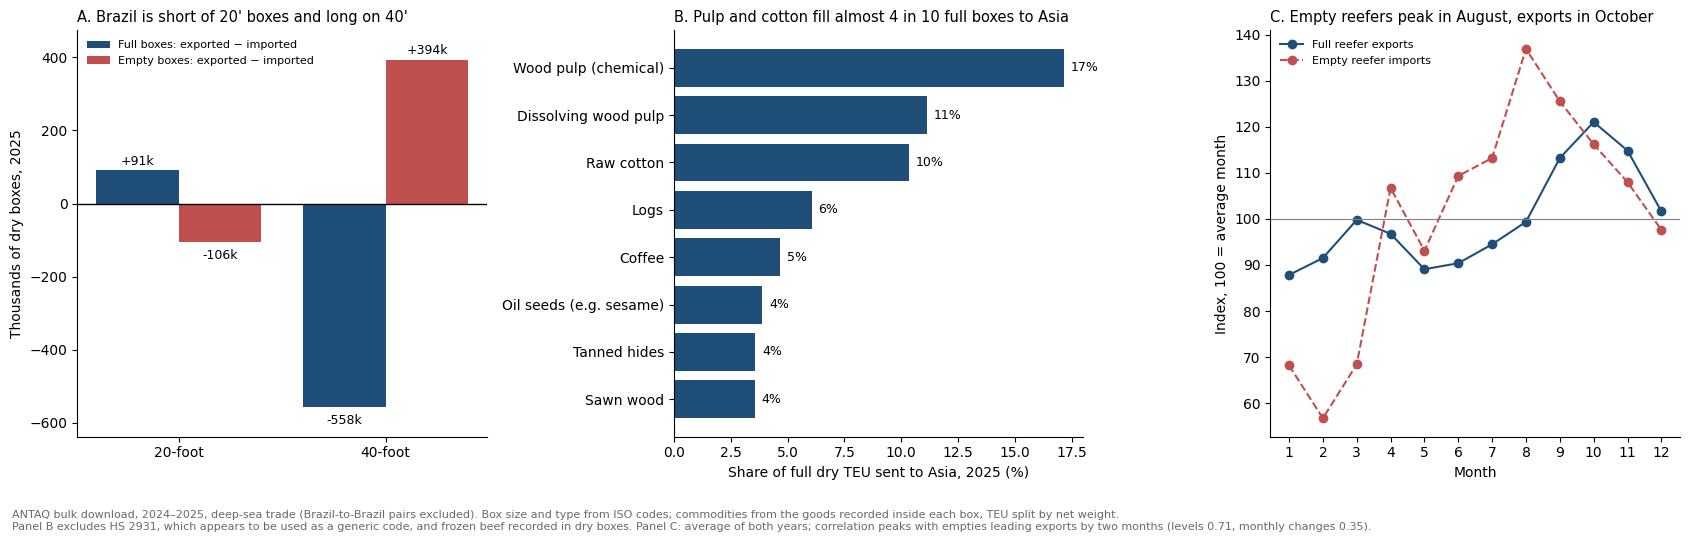

In [6]:
# 5 — Figure (fig14): size, commodity and timing of the equipment mismatch
FIG_DIR = BASE / "outputs" / "figures"
HS_NAMES = {"4703": "Wood pulp (chemical)", "4702": "Dissolving wood pulp", "5201": "Raw cotton",
            "4403": "Logs", "0901": "Coffee", "1207": "Oil seeds (e.g. sesame)", "4104": "Tanned hides",
            "4407": "Sawn wood", "1520": "Crude glycerol", "7202": "Ferro-alloys"}

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(17, 5))

# A — size mismatch, 2025, thousands of dry boxes
b = dry[dry["year"] == 2025].groupby(["size", "state", "direction"])["units"].sum() / 1e3
full_bal = [b[(s, "Full", "Export")] - b[(s, "Full", "Import")] for s in ["20", "40"]]
empty_bal = [b[(s, "Empty", "Export")] - b[(s, "Empty", "Import")] for s in ["20", "40"]]
xx = np.arange(2)
ax1.bar(xx - 0.2, full_bal, width=0.4, color="#1f4e79", label="Full boxes: exported − imported")
ax1.bar(xx + 0.2, empty_bal, width=0.4, color="#c0504d", label="Empty boxes: exported − imported")
for xi, v_ in zip(np.r_[xx - 0.2, xx + 0.2], full_bal + empty_bal):
    ax1.text(xi, v_ + (15 if v_ >= 0 else -45), f"{v_:+,.0f}k", ha="center", fontsize=9)
ax1.axhline(0, color="black", lw=1)
ax1.set_xticks(xx, ["20-foot", "40-foot"])
ax1.set_ylabel("Thousands of dry boxes, 2025")
ax1.set_ylim(min(full_bal + empty_bal) - 80, max(full_bal + empty_bal) + 80)
ax1.set_title("A. Brazil is short of 20' boxes and long on 40'", loc="left", fontsize=10.5)
ax1.legend(frameon=False, fontsize=8, loc="upper left")

# B — what fills the full dry boxes to Asia, 2025 (code 2931 and dry-recorded frozen beef excluded)
asia = y25[(y25["direction"] == "Export") & (y25["region"] == "Asia") & ~y25["sh4"].isin(["2931", "0202"])]
t = asia.groupby("sh4")["teu_alloc"].sum()
share = (100 * t / t.sum()).nlargest(8).iloc[::-1]
ax2.barh([HS_NAMES.get(c, c) for c in share.index], share, color="#1f4e79")
for i, v_ in enumerate(share):
    ax2.text(v_ + 0.3, i, f"{v_:.0f}%", va="center", fontsize=9)
ax2.set_xlabel("Share of full dry TEU sent to Asia, 2025 (%)")
ax2.set_title("B. Pulp and cotton fill almost 4 in 10 full boxes to Asia", loc="left", fontsize=10.5)

# C — reefer timing, calendar profile (average of 2024 and 2025)
idx = 100 * cal / cal.mean()
ax3.plot(idx.index, idx["Export Full"], "o-", color="#1f4e79", label="Full reefer exports")
ax3.plot(idx.index, idx["Import Empty"], "o--", color="#c0504d", label="Empty reefer imports")
ax3.axhline(100, color="grey", lw=0.8)
ax3.set_xticks(range(1, 13))
ax3.set_xlabel("Month")
ax3.set_ylabel("Index, 100 = average month")
ax3.set_title("C. Empty reefers peak in August, exports in October", loc="left", fontsize=10.5)
ax3.legend(frameon=False, fontsize=8)

for ax in (ax1, ax2, ax3):
    ax.spines[["top", "right"]].set_visible(False)

fig.text(0.01, -0.07,
         "ANTAQ bulk download, 2024–2025, deep-sea trade (Brazil-to-Brazil pairs excluded). Box size and type from ISO codes; "
         "commodities from the goods recorded inside each box, TEU split by net weight.\n"
         "Panel B excludes HS 2931, which appears to be used as a generic code, and frozen beef recorded in dry boxes. "
         "Panel C: average of both years; correlation peaks with empties leading exports by two months (levels 0.71, monthly changes 0.35).",
         fontsize=8, color="dimgrey")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig14_equipment_mismatch.png", dpi=150, bbox_inches="tight")
plt.show()

## What this notebook answers

Deep-sea container trade, 2024–2025 (Brazil-to-Brazil pairs excluded), read at the level of each cargo record: box size and type from ISO codes, goods from what is recorded inside each box.

**Is Brazil's empty-container problem only about quantity?** No. It is also about box size, cargo and timing.

- **Size: Brazil is short of 20-foot boxes and long on 40-foot ones.** 36% of full dry export boxes are 20-foot, against 23% of imports. In 2025, 91k more full 20' boxes left than arrived, and 168k empty 20' boxes were brought in. On the 40' side, 558k more full boxes arrived than left, and 598k empty 40' boxes were sent out. Almost all of the 2025 jump in empty exports (+406k of +411k TEU) was 40-foot.
- **Weight explains the size mix.** A full 40' export box weighs about the same as a full 20' one (26.4 t vs 25.3 t gross): Brazilian exports run out of weight allowance before they run out of space, so exporters prefer 20' boxes, while imports arrive in 40'.
- **Cargo: the few full boxes going to Asia depend on a handful of raw materials.** Wood pulp (28%) and raw cotton (10%) fill almost 4 in 10, followed by logs, coffee and oil seeds. Imports from Asia are far more varied: solar modules and semiconductors, integrated circuits, pesticides, tyres and cars, none above 6%.
- **Timing: empty reefers arrive about two months ahead of the export peak.** Empty reefer imports peak in August, full reefer exports in October, when beef, pork and fruit seasons stack up. Correlation is highest with a two-month lead (0.71 on monthly levels, 0.35 on monthly changes, so indicative only).
- **Reefer demand is mostly steady.** Chicken, flat across the year, accounts for about half of the main reefer exports; seasonality comes from beef, pork and fruit on top of it.

**Data quality finding.** About 325k TEU of 2025 exports are recorded under HS 2931 (organo-inorganic chemicals), 26% of them in reefers and bound mostly for transhipment hubs. The code appears to be used as a generic label and is excluded from commodity tables.

## Limitations

1. **Gross weight, not volume.** "Weight-limited exports" is inferred from gross weight per box and typical tare weights; ANTAQ does not record cubic utilisation.
2. **Commodity shares are split by net weight** when a cargo record holds several goods, and rely on how each terminal codes the cargo (see HS 2931).
3. **Last port, not final destination.** Boxes routed through hubs are not counted under Asia, so Asia figures are a lower bound.
4. **Two years of monthly data (24 points)** support the reefer timing only as an indication.
5. **No box ownership.** Shipper-owned and leased boxes cannot be separated from carrier-owned ones.